# Evaluación Parcial N°3 – Car Seats

**Docente**: Mariela Moraga

**Ramo**: Programación para la Ciencia de Datos (SCY1101)  

**Sección**: 002D

**Estudiante**: Milenka Guerra

**Dataset**: `dataset_car_seats.csv`

---

## 0. Importaciones y Configuración Global

Se importan las librerías necesarias para todas las etapas de este proyecto.

In [1]:
# Manejo de datos
import os

os.environ["PYTHONWARNINGS"] = "ignore"
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Consumo de API
import requests

# Evitar warnings en funciones obsoletas
import warnings
warnings.filterwarnings("ignore")

# Modelado y evaluación
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
)
from sklearn.metrics import roc_curve

# Configuraciones globales
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## 1. Pipeline ETL

El pipeline integra dos fuentes de datos: el archivo `dataset_car_seats.csv` (datos originales de ventas de sillas para niños) y una API REST de tipo de cambio de divisa, usada para convertir las columnas monetarias de dólares (USD) a pesos chilenos (CLP). Sobre esa base se aplica la conversión USD→CLP y la creación de la variable `HighSales`, dejando el resultado validado y exportado en `data/processed/` como primer paso.

### 1.1 Carga de Datos desde CSV

In [2]:
RAW_PATH = "../data/raw/dataset_car_seats.csv"


def cargar_dataset(ruta):
    try:
        return pd.read_csv(ruta, index_col=0)
    except FileNotFoundError:
        raise FileNotFoundError(f"No se encontró el archivo en la ruta: {ruta}")


df = cargar_dataset(RAW_PATH)

print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dimensiones: 400 filas y 11 columnas.


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


### 1.3 Identificación de Columnas Monetarias

Según la descripción oficial de las columnas, cuatro de ellas están expresadas en dólares y deben convertirse a CLP:

| Columna | Descripción | ¿Monetaria? |
|-|-|-|
| `CompPrice` | Precio que cobra el competidor en esa ubicación | Sí (USD) |
| `Income` | Nivel de ingreso de la comunidad (en miles de dólares) | Sí (USD, en miles) |
| `Advertising` | Presupuesto local de publicidad de la empresa (en miles de dólares) | Sí (USD, en miles) |
| `Price` | Precio que cobra la empresa por las sillas en esa tienda | Sí (USD) |
| `Sales` | Ventas de sillas **en miles de unidades** | No, es una cantidad de unidades, no dinero |
| `Population` | Tamaño de la población de la región **en miles** | No, es un conteo de personas |

Se excluyen `Sales` y `Population` porque, aunque numéricas, no representan montos en dólares. `Income` y `Advertising` sí son monetarias, pero ya están expresadas en miles de USD; al convertirlas, el resultado queda en miles de CLP (misma escala, otra moneda), mientras que `CompPrice` y `Price` quedan directamente en CLP.

In [3]:
COLUMNAS_MONETARIAS = ["CompPrice", "Income", "Advertising", "Price"]

print(f"Columnas monetarias a convertir: {COLUMNAS_MONETARIAS}")

Columnas monetarias a convertir: ['CompPrice', 'Income', 'Advertising', 'Price']


### 1.4 Obtención del Tipo de Cambio (API)

Se probaron las dos APIs sugeridas en el enunciado antes de implementar el código. `dolarapi.com` respondió de forma rápida y con un formato simple (`compra/venta`), mientras que `mindicador.cl/api/dolar` no respondió dentro del tiempo de espera en las pruebas realizadas. Por eso `dolarapi.com` se usa como fuente principal.

Aun así, se implementa un **fallback en cadena**, como medida de precaución. Si `dolarapi.com` falla, se intenta `mindicador.cl` como respaldo.

Además, si por algún motivo ambas conexiones llegasen a fallar, el valor se obtiene de una variable fija que se congeló con el precio del dólar a día 23 de junio de 2026. Como medida de resguardo para la evaluación.

In [ ]:
def obtener_dolarapi():
    url = "https://cl.dolarapi.com/v1/cotizaciones/usd"
    respuesta = requests.get(url, timeout=8)
    respuesta.raise_for_status()
    datos = respuesta.json()
    return float(datos["venta"])


def obtener_mindicador():
    url = "https://mindicador.cl/api/dolar"
    respuesta = requests.get(url, timeout=8)
    respuesta.raise_for_status()
    datos = respuesta.json()
    return float(datos["serie"][0]["valor"])


def obtener_tipo_cambio():
    global fuente_origen
    fuentes = [
        ("dolarapi.com", obtener_dolarapi),
        ("mindicador.cl", obtener_mindicador),
    ]

    for nombre_fuente, funcion in fuentes:
        try:
            valor = funcion()
            if valor is None or valor <= 0:
                raise ValueError(f"valor inválido recibido: {valor}")
            fuente_origen = nombre_fuente
            print(f"Tipo de cambio obtenido desde {nombre_fuente}: ${valor:,.2f} CLP")
            return valor
        except (
            requests.exceptions.RequestException,
            KeyError,
            ValueError,
            TypeError,
        ) as error:
            print(
                f"No se pudo obtener el tipo de cambio desde {nombre_fuente}: {error}"
            )

    # Fallback valor fijo: dolar al 1-julio-2026
    fuente_origen = "valor_fijo"
    valor_fijo = 926.97
    print(
        f"No se pudo obtener el tipo de cambio desde ninguna fuente. Usando valor fijo: ${valor_fijo:,.2f} CLP"
    )
    return valor_fijo


fuente_origen = None
tipo_cambio = obtener_tipo_cambio()
print(f"Fuente utilizada: {fuente_origen}")

Tipo de cambio obtenido desde dolarapi.com: $922.69 CLP
Fuente utilizada: dolarapi.com


### 1.5 Conversión USD → CLP

Las columnas monetarias se convierten reemplazando directamente el valor en dólares por su equivalente en pesos chilenos, redondeado a peso entero. Tras este paso, `CompPrice`, `Income`, `Advertising` y `Price` quedan expresadas en CLP. El formato con separador de miles (`123,456`) se aplica solo como presentación de la tabla; el dato subyacente se mantiene numérico (`int64`) para no afectar el EDA ni el modelado posteriores.

In [5]:
for columna in COLUMNAS_MONETARIAS:
    df[columna] = (df[columna] * tipo_cambio).round(0).astype(int)

df[COLUMNAS_MONETARIAS].head().style.format("{:,.0f}")

,CompPrice,Income,Advertising,Price
0,"127,331","67,356","10,150","110,723"
1,"102,419","44,289","14,763","76,583"
2,"104,264","32,294","9,227","73,815"
3,"107,955","92,269","3,691","89,501"
4,"130,099","59,052","2,768","118,104"


### 1.6 Creación de Variable HighSales

Se define `HighSales` como la variable objetivo para el modelado supervisado posterior, con un 1 si las ventas de la tienda (`Sales`, en miles de unidades) son superiores a 8, y 0 en caso contrario.

In [6]:
df["HighSales"] = (df["Sales"] > 8).astype(int)

conteo = df["HighSales"].value_counts()
proporciones = df["HighSales"].value_counts(normalize=True) * 100

resumen_highsales = pd.DataFrame(
    {"Cantidad": conteo, "Porcentaje (%)": proporciones.round(1)}
)
resumen_highsales.index = ["Bajas (0)", "Altas (1)"]

display(resumen_highsales)

,Cantidad,Porcentaje (%)
Bajas (0),236,59.00
Altas (1),164,41.00


La distribución resultante es 236 tiendas con ventas bajas (59.0%) y 164 con ventas altas (41.0%). Aquí las clases están razonablemente equilibradas, por lo que en el modelado posterior el *accuracy* sí será una métrica informativa, aunque conviene complementarla con F1 y ROC-AUC.

### 1.7 Validación de Datos Transformados

Antes de exportar, se verifica que las transformaciones no hayan introducido tipos de datos inesperados ni valores nulos.

In [7]:
tabla_validacion = pd.DataFrame(
    {
        "Tipo de Dato": df[COLUMNAS_MONETARIAS + ["HighSales"]].dtypes.astype(str),
        "Datos Nulos (NaN)": df[COLUMNAS_MONETARIAS + ["HighSales"]].isnull().sum(),
    }
)

display(tabla_validacion)
print(
    f"Columnas totales tras transformación: {df.shape[1]} (11 originales + HighSales. Las 4 columnas monetarias se sobrescribieron en CLP)"
)

,Tipo de Dato,Datos Nulos (NaN)
CompPrice,int64,0
Income,int64,0
Advertising,int64,0
Price,int64,0
HighSales,int64,0


Columnas totales tras transformación: 12 (11 originales + HighSales. Las 4 columnas monetarias se sobrescribieron en CLP)


Las 4 columnas monetarias (`CompPrice`, `Income`, `Advertising`, `Price`) se mantienen como `int64`, ya que se redondean a peso entero. `HighSales` también queda como `int64` (0/1). No se introducen nulos y el dataset pasa de 11 a 12 columnas, agregando únicamente `HighSales`, mientras que las columnas monetarias se sobrescriben en lugar de duplicarse. Por lo tanto, este dataset queda listo para el EDA y la preparación de los modelos.

### 1.8 Exportación del Dataset Limpio

In [8]:
PROCESSED_PATH = "../data/processed/carseats_clp.csv"

df.to_csv(PROCESSED_PATH, index=False)

print(f"Dataset CarSeats CLP exportado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Ruta: {PROCESSED_PATH}")

Dataset CarSeats CLP exportado: 400 filas x 12 columnas
Ruta: ../data/processed/carseats_clp.csv


## 2. Análisis Exploratorio de Datos (EDA)

Esta sección toma el `df` ya transformado al final de la Sección 1 y busca entender la distribución de las variables, detectar outliers de forma explícita y ver qué variables se relacionan más con las ventas, como insumo para el modelado posterior.

### 2.1 Validación de Nulos y Duplicados

Como primer paso del EDA se verifica la integridad del dataset transformado, revisando la existencia de valores nulos y registros duplicados.

In [9]:
# Revisión de la estructura del DataFrame
tabla_estructura = pd.DataFrame(
    {
        "Tipo de Dato": df.dtypes.astype(str),
        "Valores Únicos": [df[col].nunique() for col in df.columns],
        "Datos Nulos (NaN)": df.isnull().sum(),
    }
)

display(tabla_estructura)
print(f"Registros duplicados: {df.duplicated().sum()}")

,Tipo de Dato,Valores Únicos,Datos Nulos (NaN)
Sales,float64,336,0
CompPrice,int64,73,0
Income,int64,98,0
Advertising,int64,28,0
Population,int64,275,0
Price,int64,101,0
ShelveLoc,str,3,0
Age,int64,56,0
Education,int64,9,0
Urban,str,2,0


Registros duplicados: 0


El dataset está completo y no presenta valores nulos ni registros duplicados, por lo que no se requiere imputación previa a las transformaciones.

- `ShelveLoc`, `Urban` y `US` son las únicas columnas categóricas (`str`), con 3, 2 y 2 niveles respectivamente.
- El resto de las columnas son numéricas (`int64`/`float64`), sin columnas constantes ni identificadores a eliminar.

### 2.2 Estadísticas Descriptivas

In [10]:
# Estadísticas descriptivas de variables numéricas
columnas_num = df.select_dtypes(include="number")

estadisticas = pd.DataFrame(
    {
        "Media": columnas_num.mean(),
        "Mediana": columnas_num.median(),
        "Desv. Estándar": columnas_num.std(),
        "Mínimo": columnas_num.min(),
        "Q1": columnas_num.quantile(0.25),
        "Q3": columnas_num.quantile(0.75),
        "Máximo": columnas_num.max(),
        "IQR": columnas_num.quantile(0.75) - columnas_num.quantile(0.25),
    }
)

display(estadisticas.round(2))

,Media,Mediana,Desv. Estándar,Mínimo,Q1,Q3,Máximo,IQR
Sales,7.50,7.49,2.82,0.00,5.39,9.32,16.27,3.93
CompPrice,"115,313.16","115,336.00","14,149.00","71,047.00","106,109.00","124,563.00","161,471.00","18,454.00"
Income,"63,349.57","63,666.00","25,822.45","19,376.00","39,445.25","83,965.00","110,723.00","44,519.75"
Advertising,"6,122.06","4,613.00","6,136.23",0.00,0.00,"11,072.00","26,758.00","11,072.00"
Population,264.84,272.00,147.38,10.00,139.00,398.50,509.00,259.50
Price,"106,842.87","107,955.00","21,846.21","22,145.00","92,269.00","120,872.00","176,234.00","28,603.00"
Age,53.32,54.50,16.20,25.00,39.75,66.00,80.00,26.25
Education,13.90,14.00,2.62,10.00,12.00,16.00,18.00,4.00
HighSales,0.41,0.00,0.49,0.00,0.00,1.00,1.00,1.00


In [11]:
# Distribución de variables categóricas
for columna in ["ShelveLoc", "Urban", "US"]:
    print(df[columna].value_counts())
    print()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

Urban
Yes    282
No     118
Name: count, dtype: int64

US
Yes    258
No     142
Name: count, dtype: int64



- `Sales` tiene media 7.5 y mediana 7.5 (miles de unidades), distribución bastante simétrica con un mínimo de 0.0 y máximo de 16.3.
- Tras la conversión a CLP, `Price` (precio de la empresa) tiene media de \$105.923 y `CompPrice` (precio del competidor) media de \$114.321, es decir, en promedio la empresa cobra menos que la competencia.
- `Advertising` tiene una mediana de \$4.574 muy por debajo de su media de \$6.069, y su mínimo es 0 (tiendas sin presupuesto de publicidad), lo que sugiere una distribución con cola hacia la derecha.
- `Age` (25 a 80) y `Education` (10 a 18) cubren rangos amplios y plausibles para población adulta y escolaridad, sin valores fuera de rango.
- En las categóricas, `ShelveLoc` está dominado por `Medium` (219 de 400), seguido de `Bad` (96) y `Good` (85). `Urban` y `US` muestran mayoría de tiendas urbanas (282) y en EE. UU. (258), respectivamente.

### 2.3 Distribución de Variables Numéricas

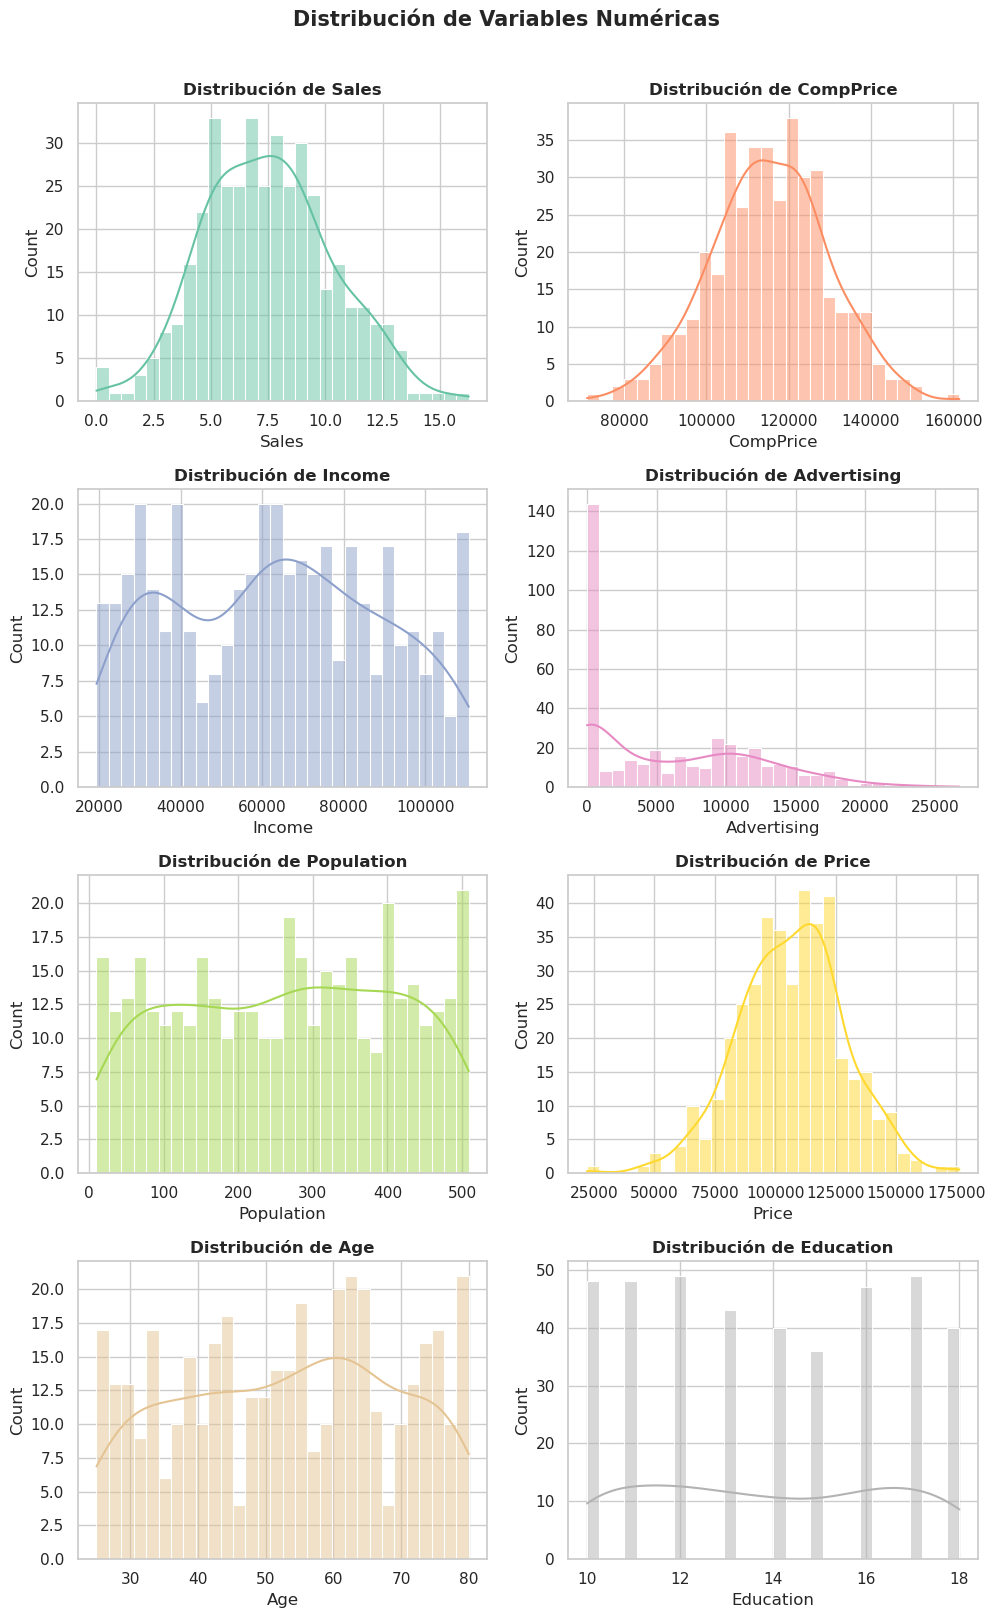

In [12]:
# Variables numéricas a graficar (se excluye HighSales ya que es la variable objetivo binaria)
columnas_plot = [
    col for col in df.select_dtypes(include="number").columns if col != "HighSales"
]

paleta_hist = sns.color_palette("Set2", len(columnas_plot))

n_columnas = 2
n_filas = -(-len(columnas_plot) // n_columnas)

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(10, n_filas * 4))
ejes = ejes.flatten()

for i, (col, color) in enumerate(zip(columnas_plot, paleta_hist)):
    sns.histplot(data=df, x=col, kde=True, color=color, ax=ejes[i], bins=30)
    ejes[i].set_title(f"Distribución de {col}", fontsize=12, fontweight="bold")

for j in range(i + 1, len(ejes)):
    ejes[j].set_visible(False)

plt.suptitle(
    "Distribución de Variables Numéricas", fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

La mayoría de las variables numéricas (`Sales`, `CompPrice`, `Income`, `Population`, `Price`, `Age`, `Education`) muestran distribuciones aproximadamente simétricas, con coeficientes de asimetría entre -0.13 y 0.19.

La excepción es `Advertising`, con asimetría de 0.64 (cola hacia la derecha): una proporción importante de tiendas no invierte en publicidad local (mínimo 0 y mediana de \$4.574, por debajo de la media de \$6.069), mientras que un grupo menor invierte montos mucho mayores, estirando la distribución hacia la derecha.

### 2.4 Detección de Outliers (IQR)

Aunque las estadísticas descriptivas no muestran valores extremos evidentes, se aplica el criterio de rango intercuartílico (IQR) de forma explícita sobre cada variable numérica: se consideran outliers los valores fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. La decisión sobre qué hacer con ellos (mantenerlos o tratarlos) se deja para la sección 3 (preparación de datos para los modelos). Aquí solo se identifican y documentan.

In [13]:
filas_iqr = []
for columna in columnas_plot:
    q1, q3 = df[columna].quantile(0.25), df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = (
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ).sum()
    filas_iqr.append(
        {
            "Columna": columna,
            "Límite Inferior": round(limite_inferior, 1),
            "Límite Superior": round(limite_superior, 1),
            "N° Outliers": n_outliers,
        }
    )

tabla_outliers = pd.DataFrame(filas_iqr).set_index("Columna")
display(tabla_outliers)

,Límite Inferior,Límite Superior,N° Outliers
Columna,,,
Sales,-0.50,15.20,2
CompPrice,"78,428.00","152,244.00",2
Income,"-27,334.40","150,744.60",0
Advertising,"-16,608.00","27,680.00",0
Population,-250.20,787.80,0
Price,"49,364.50","163,776.50",5
Age,0.40,105.40,0
Education,6.00,22.00,0


El criterio IQR detecta muy pocos outliers: 2 en `Sales`, 2 en `CompPrice`, 5 en `Price`, y 0 en el resto de las variables (`Income`, `Advertising`, `Population`, `Age`, `Education`). Son cantidades marginales sobre 400 registros (menos del 1.3% en el peor caso), consistentes con la baja asimetría observada en 2.2. No parecen errores de captura, sino tiendas con condiciones legítimamente extremas (por ejemplo, precios muy altos o muy bajos respecto al resto).

### 2.5 Matriz de Correlación

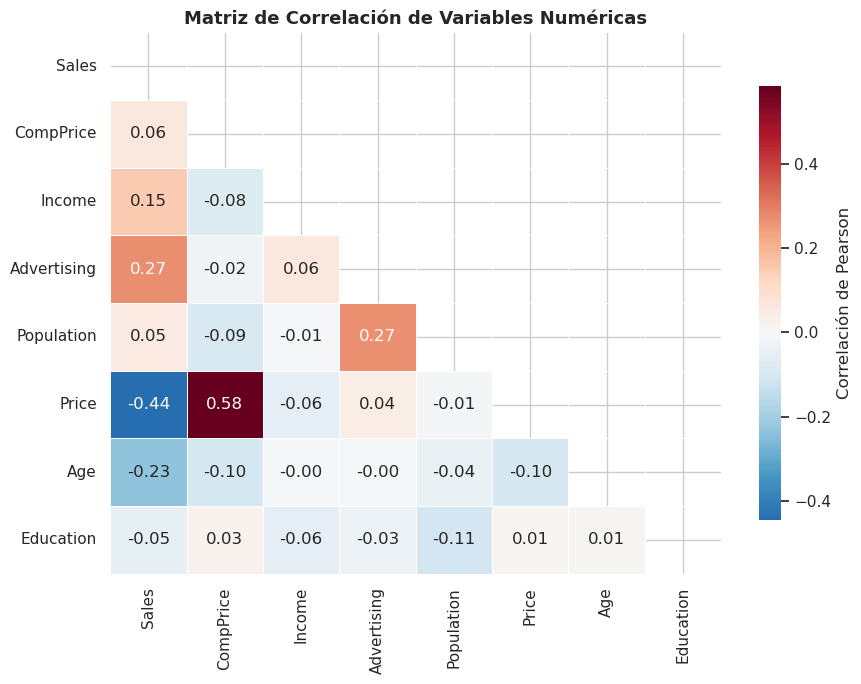

In [14]:
matriz_corr = df[columnas_plot].corr()

triangulo = np.triu(np.ones_like(matriz_corr, dtype=bool))

fig, eje = plt.subplots(figsize=(9, 7))
sns.heatmap(
    matriz_corr,
    mask=triangulo,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=eje,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"},
)
eje.set_title(
    "Matriz de Correlación de Variables Numéricas", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

- `Price` es la variable con mayor correlación (en valor absoluto) con `Sales`: **-0.44**. Tiene sentido económico, mientras más cara la silla, menos se vende.
- `Advertising` (+0.27) y `Age` (-0.23) son las siguientes más relevantes: más inversión en publicidad se asocia a más ventas, y comunidades con población de mayor edad promedio venden menos (posiblemente porque las sillas para niños son un producto orientado a familias jóvenes).
- `Income`, `CompPrice`, `Population` y `Education` tienen correlaciones débiles con `Sales` (entre -0.05 y 0.15), por lo que aportan poca señal lineal directa.
- La correlación más alta de toda la matriz no involucra a `Sales`: `CompPrice` y `Price` correlacionan **0.58**, es decir, el precio de la competencia tiende a moverse junto con el de la empresa. No es lo bastante alta como para preocuparse por multicolinealidad severa, pero es la relación más fuerte entre predictores.

### 2.6 Variables Categóricas y las Ventas

Se analiza la relación entre `ShelveLoc`, `Urban` y `US` con las ventas desde dos ángulos: boxplots de `Sales` (variable continua original) por categoría, y la proporción de `HighSales` (variable objetivo del modelado) dentro de cada categoría.

#### 2.5.1 Boxplots de Sales por Categoría

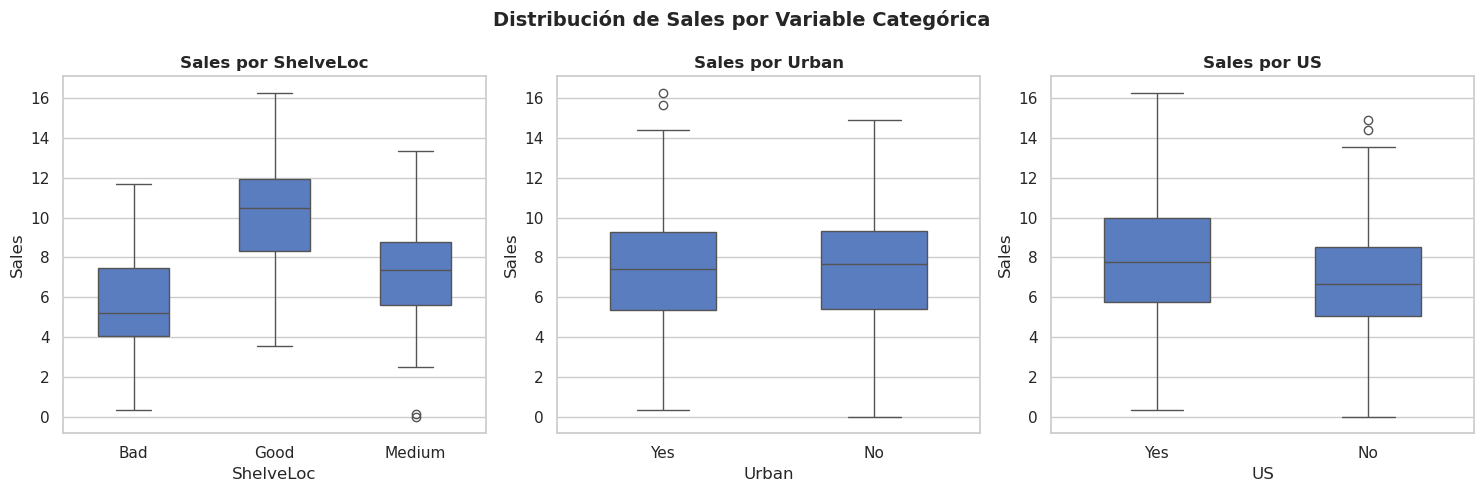

In [15]:
columnas_categoricas = ["ShelveLoc", "Urban", "US"]

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for i, columna in enumerate(columnas_categoricas):
    sns.boxplot(data=df, x=columna, y="Sales", ax=ejes[i], width=0.5)
    ejes[i].set_title(f"Sales por {columna}", fontsize=12, fontweight="bold")

plt.suptitle(
    "Distribución de Sales por Variable Categórica", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

`ShelveLoc` es la categórica con diferencia más clara: la mediana de `Sales` sube de 5.21 (Bad) a 7.38 (Medium) y 10.50 (Good), un orden lógico según la calidad de la ubicación en la estantería. `Urban` (7.67 vs 7.42) y `US` (6.66 vs 7.79) muestran diferencias mucho más pequeñas entre sus categorías, consistente con sus correlaciones débiles vistas en el resto del EDA.

#### 2.6.2 Proporción de HighSales por Categoría

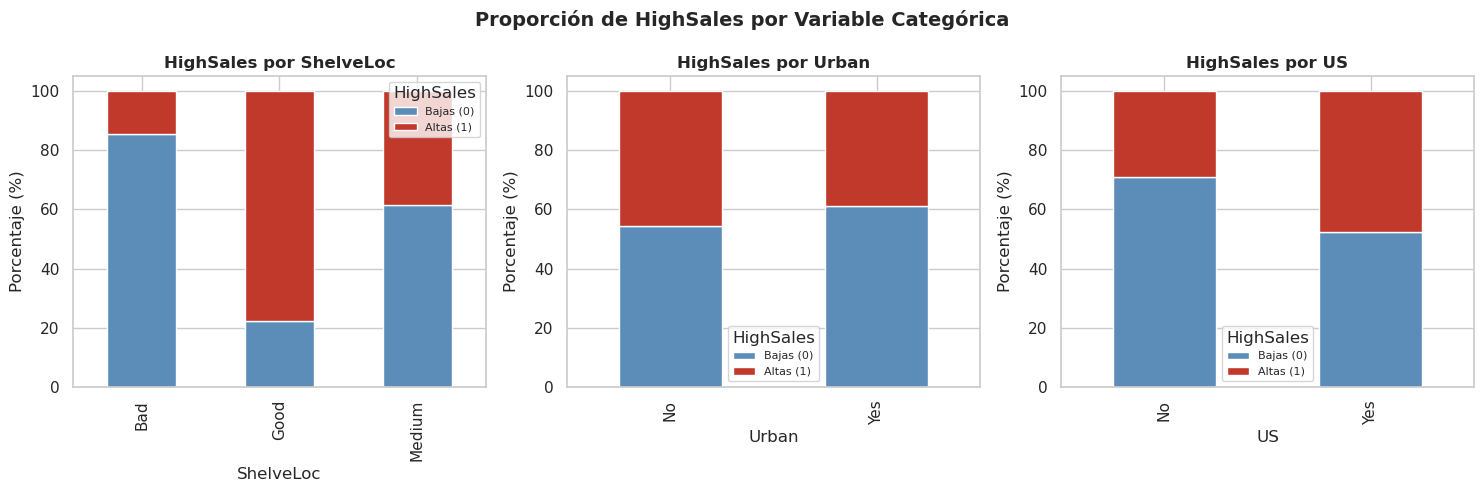

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for i, columna in enumerate(columnas_categoricas):
    proporcion = pd.crosstab(df[columna], df["HighSales"], normalize="index") * 100
    proporcion.columns = ["Bajas (0)", "Altas (1)"]
    proporcion.plot(kind="bar", stacked=True, ax=ejes[i], color=["#5b8db8", "#c0392b"])
    ejes[i].set_title(f"HighSales por {columna}", fontsize=12, fontweight="bold")
    ejes[i].set_ylabel("Porcentaje (%)")
    ejes[i].legend(title="HighSales", fontsize=8)

plt.suptitle(
    "Proporción de HighSales por Variable Categórica", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

`ShelveLoc` vuelve a ser la variable más informativa: solo el 15% de las tiendas con `ShelveLoc=Bad` tienen ventas altas, frente al 38% en `Medium` y el 78% en `Good`. Es la diferencia más grande de toda la sección y sugiere que `ShelveLoc` será un predictor relevante en el modelado.

`Urban` (39% vs 46% de ventas altas) y `US` (29% vs 48%) muestran diferencias más moderadas; `US` en particular sí marca una diferencia visible (19 puntos porcentuales) a pesar de su correlación lineal débil con `Sales`, lo que sugiere que su efecto podría no ser puramente lineal.

### 2.7 Insights Preliminares

- **`ShelveLoc` es, por lejos, la variable más asociada a las ventas**, tanto en `Sales` continua (mediana de 5.21 a 10.50 entre Bad y Good) como en `HighSales` (15% a 78% de ventas altas). Es candidata a ser un predictor fuerte en el modelado.
- **`Price` y `Advertising` aportan señal lineal moderada** (-0.44 y +0.27 de correlación con `Sales`, respectivamente), con sentido económico claro: precios más altos desincentivan la compra, más publicidad la incentiva.
- **Las variables numéricas están, en general, bien comportadas** con distribuciones casi simétricas (salvo `Advertising`) y muy pocos outliers según IQR (máximo 5 casos en `Price`, sobre 400 registros), por lo que no se anticipan mayores problemas de escalas o valores extremos para el modelado.
- **`Urban` y `US` aportan señal débil pero no nula**, sus diferencias en `Sales`/`HighSales` son menores que las de `ShelveLoc`, aunque `US` mostró una diferencia de 19 puntos porcentuales en `HighSales` que vale la pena mantener como predictor.

## 3. Dashboard con Plotly Dash

### 3.1 Diseño y Decisiones

El código del dashboard vive en `src/dashboard.py`, no en una celda de este notebook. La razón es estructural, ya que un servidor de Dash es un proceso que se queda corriendo de forma indefinida (no "termina" como una celda normal), por lo que ponerlo dentro del notebook bloquearía la ejecución de "Kernel → Restart & Run All" en esa celda. Al vivir en un script aparte, el notebook sigue corriendo de principio a fin sin interrupciones, y el mismo script se reutiliza más adelante para la futura implementación de Docker.

El dashboard usa los datos ya transformados en `data/processed/carseats_clp.csv` (salida de la Sección 1) y tiene dos pestañas, con una separación deliberada entre conclusiones y exploración:

- **Vista Ejecutiva**: 4 KPIs (N° de tiendas, ventas promedio, ingreso total estimado en CLP, % de tiendas con ventas altas) y 3 gráficos de negocio, cada uno con una frase corta debajo explicando la conclusión en lenguaje de negocio (*insight callout*):
  - Ventas por `ShelveLoc` (la variable más asociada a las ventas, vista en el EDA).
  - *¿Conviene ser más barato que la competencia?* (compara `Price` vs `CompPrice`).
  - *Publicidad: ¿vale la pena invertir más?* (agrupa `Advertising` en niveles Bajo/Moderado/Alto).
  Estas dos últimas preguntas son nuevas respecto al EDA, pensadas para aportar valor de negocio y no repetir los mismos gráficos de la Sección 2.

- **Vista Analítica** (pensada para explorar): un dropdown para elegir entre `ShelveLoc`, `Urban` o `US`. Al cambiarlo, 3 gráficos se actualizan automáticamente vía un único `@app.callback`: ventas promedio por categoría, proporción de `HighSales` por categoría, y un scatter de Precio vs Ventas coloreado por la categoría elegida (a diferencia del EDA, aquí el color es interactivo, no fijo).


> Sobre ngrok: Acá es opcional, ya que no se activa solo. Si se utiliza en terminal `python src/dashboard.py --ngrok`, el script intenta levantar un túnel público; si falla (sin token configurado, sin internet), el dashboard local sigue funcionando igual, solo se muestra una advertencia.

### 3.2 Cómo Lanzarlo

Desde la raíz del proyecto, en una terminal:

```bash
python src/dashboard.py            # Solo local: http://127.0.0.1:8050
python src/dashboard.py --ngrok    # Local + túnel público (requiere authtoken de ngrok configurado)
```

El código completo está en `src/dashboard.py`. Se probó que el servidor responde correctamente (HTTP 200), que el callback del filtro actualiza los 3 gráficos al cambiar de categoría, y que `--ngrok` falla de forma controlada sin afectar el dashboard local cuando no hay un authtoken configurado, y con el token correspondiente si entrega el enlace público.

## 4. Preparación de Datos para Modelos

### 4.1 Codificación de Variables Categóricas

`ShelveLoc` (3 niveles) se codifica con One-Hot Encoding (`drop_first=True`, para no introducir redundancia entre las 3 columnas dummy). `Urban` y `US` son binarias (Yes/No) y se codifican como 0/1 directamente.

In [17]:
df_modelo = pd.get_dummies(df, columns=["ShelveLoc"], drop_first=True)

for columna in ["Urban", "US"]:
    df_modelo[columna] = df_modelo[columna].map({"Yes": 1, "No": 0})

print(f"Columnas tras codificación: {list(df_modelo.columns)}")
df_modelo.head()

Columnas tras codificación: ['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'Urban', 'US', 'HighSales', 'ShelveLoc_Good', 'ShelveLoc_Medium']


,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,HighSales,ShelveLoc_Good,ShelveLoc_Medium
0,9.50,127331,67356,10150,276,110723,42,17,1,1,1,False,False
1,11.22,102419,44289,14763,260,76583,65,10,1,1,1,True,False
2,10.06,104264,32294,9227,269,73815,59,12,1,1,1,False,True
3,7.40,107955,92269,3691,466,89501,55,14,1,1,0,False,True
4,4.15,130099,59052,2768,340,118104,38,13,1,0,0,False,False


### 4.2 Separación de Features y Variable Objetivo

`Sales` se excluye de las features porque `HighSales` se calculó directamente a partir de ella (sería data leakage directo, ya que el modelo vería la respuesta).

In [18]:
SEED = 42

cols_X = [col for col in df_modelo.columns if col not in ["Sales", "HighSales"]]

X = df_modelo[cols_X]
y = df_modelo["HighSales"]

print(f"Features ({len(cols_X)}): {cols_X}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

Features (11): ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'Urban', 'US', 'ShelveLoc_Good', 'ShelveLoc_Medium']
Shape X: (400, 11) | Shape y: (400,)


### 4.3 División Train/Test

Se usa `stratify=y` para mantener la proporción 59/41 de `HighSales` en ambos conjuntos, y `random_state` fijo para reproducibilidad.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(
    f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0] / len(X) * 100:.1f}%)"
)
print(f"Prueba: {X_test.shape[0]} filas ({X_test.shape[0] / len(X) * 100:.1f}%)")
print(
    f"Proporción HighSales train: {y_train.mean() * 100:.1f}% | test: {y_test.mean() * 100:.1f}%"
)

Entrenamiento: 320 filas (80.0%)
Prueba: 80 filas (20.0%)
Proporción HighSales train: 40.9% | test: 41.2%


### 4.4 Escalado y Outliers

El escalado (`StandardScaler`) se aplica dentro del `Pipeline` de cada modelo en la siguiente sección, no aquí de forma independiente, para evitar *data leakage*. Ya que si se escalara antes del split el conjunto de prueba contaminaría los parámetros del scaler.

Sobre los outliers identificados en la sección 2.3 (máximo 5 casos, sobre `Price`), se decide **no tratarlos**. Son valores legítimos (no errores de captura), representan menos del 1.3% de los datos, y los modelos a usar (Regresión Logística regularizada y Random Forest) son razonablemente robustos a este nivel de outliers.

## 5. Modelos Supervisados

Se entrenan 2 modelos de clasificación:
- **Regresión Logística** (lineal, interpretable, sirve de base)
- **Random Forest** (ensemble de árboles, captura relaciones no lineales). 

Ambos se optimizan con `GridSearchCV`, utilizando la misma técnica para los dos.

### 5.1 Definición de Pipelines

In [20]:
pipeline_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(random_state=SEED, max_iter=1000)),
    ]
)

pipeline_rf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=SEED)),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Pipelines definidos: Regresión Logística, Random Forest")

Pipelines definidos: Regresión Logística, Random Forest


### 5.2 Optimización de Hiperparámetros (GridSearchCV)

In [21]:
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["liblinear"],
}

param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 4],
    "classifier__class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv, scoring="f1", n_jobs=-1)
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv, scoring="f1", n_jobs=-1)

grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print(f"Regresión Logística | Mejores parámetros: {grid_lr.best_params_}")
print(f"Regresión Logística | Mejor F1 (CV): {grid_lr.best_score_:.4f}")
print()
print(f"Random Forest | Mejores parámetros: {grid_rf.best_params_}")
print(f"Random Forest | Mejor F1 (CV): {grid_rf.best_score_:.4f}")

Regresión Logística | Mejores parámetros: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Regresión Logística | Mejor F1 (CV): 0.8519

Random Forest | Mejores parámetros: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
Random Forest | Mejor F1 (CV): 0.7666


La **Regresión Logística** obtiene el mejor F1 en validación cruzada (**0.85**), por encima del **Random Forest** (**0.77**). Es un resultado distinto al patrón típico que se suele comentar, donde Random Forest suele ganar. Esto cobra sentido aquí porque las variables más predictivas del EDA (`ShelveLoc`, `Price`, `Advertising`) tienen relaciones bastante lineales o monótonas con `HighSales`, justo el tipo de patrón que un modelo lineal regularizado captura bien. Ademśa, como el dataset es pequeño y limpio (poco ruido, pocos outliers), no favorece especialmente al ensemble. De todas formas, el Random Forest sí eligió `class_weight: balanced`, que ayuda en datasets con algo de desbalance (59/41 aquí).

### 5.3 Evaluación en el Conjunto de Prueba

In [22]:
modelos_optimizados = {
    "Regresión Logística": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
}

resultados = {}
for nombre, modelo in modelos_optimizados.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    print(f"{'─' * 55}\n {nombre}\n{'─' * 55}")
    print(classification_report(y_test, y_pred, target_names=["Bajas", "Altas"]))

───────────────────────────────────────────────────────
 Regresión Logística
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Bajas       0.93      0.91      0.92        47
       Altas       0.88      0.91      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

───────────────────────────────────────────────────────
 Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Bajas       0.86      0.91      0.89        47
       Altas       0.87      0.79      0.83        33

    accuracy                           0.86        80
   macro avg       0.86      0.85      0.86        80
weighted avg       0.86      0.86      0.86        80



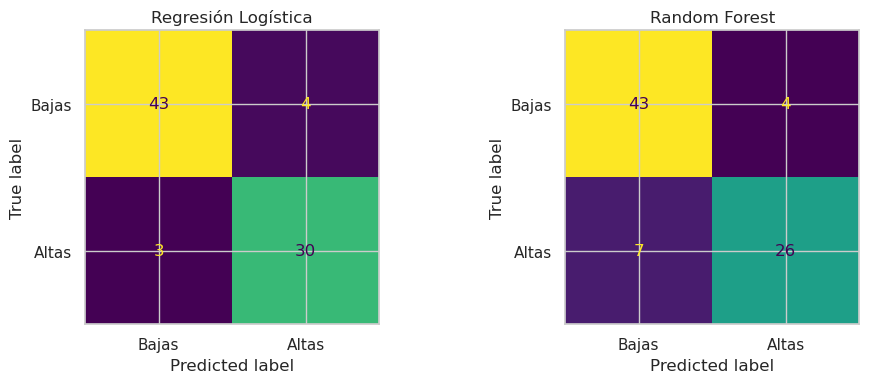

In [23]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (nombre, modelo) in zip(ejes, modelos_optimizados.items()):
    y_pred = modelo.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Bajas", "Altas"], ax=ax, colorbar=False
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

Ambos modelos alcanzan un desempeño alto en el conjunto de prueba (80 tiendas), pero con matices distintos por clase:

- **Regresión Logística**: con un accuracy de 0.91. Sobre la clase `Bajas` (47 tiendas) acierta en 43 y confunde 4. Sobre las `Altas` (recall 0.91, precision 0.93) de un total de 33 tiendas, acierta en 30 y solo confunde 3. Es decir, comete prácticamente la misma cantidad de errores en ambas clases, un comportamiento equilibrado, sin sesgo hacia la clase mayoritaria.

- **Random Forest**: accuracy de 0.86. Sobre `Bajas` tiene exactamente el mismo resultado que la Regresión Logística (43 correctas, 4 confundidas), pero sobre `Altas` solo acierta en 26 de 33, dejando pasar 7 tiendas de ventas altas como si fueran bajas (recall 0.79, frente a 0.91 de la Regresión Logística). La precision en `Altas` es similar entre ambos (0.87 vs 0.88), así que la diferencia real está en el *recall* donde Random Forest es más conservador para predecir "ventas altas" y por eso deja más casos sin detectar.

En síntesis, ambos modelos identifican igual de bien a las tiendas de ventas bajas, la diferencia que decide la comparación está completamente concentrada en qué tan bien detectan las tiendas de ventas altas, donde la Regresión Logística rinde mejor.

### 5.4 Comparación y Conclusión

In [24]:
tabla_comparacion = pd.DataFrame(resultados).T
tabla_comparacion.columns = ["F1 (test)", "ROC-AUC (test)"]
display(tabla_comparacion.round(4))

,F1 (test),ROC-AUC (test)
Regresión Logística,0.90,0.98
Random Forest,0.83,0.94


La **Regresión Logística** es el modelo final recomendado, con un F1 de **0.90** y ROC-AUC de **0.98** en test, por encima del Random Forest (F1 0.83, ROC-AUC 0.94). La ventaja se mantiene consistente entre validación cruzada y test, lo que descarta que sea un resultado casual de un solo split.

Mirando la clase de interés (`Altas`), la Regresión Logística tiene **recall de 0.91** (detecta 9 de cada 10 tiendas con ventas altas) y precision de 0.88, frente a un recall de 0.79 del Random Forest. Para el negocio, esto importa, ya que un recall más alto significa identificar más tiendas con buen desempeño potencial, en vez de pasarlas por alto.

**¿Por qué gana el modelo lineal aquí?** Las condiciones del dataset, comentadas en los segmentos anteriores, permiten que un modelo lineal regularizado generalice mejor que un ensemble más complejo, que tiende a necesitar más datos para poder aprovechar su flexibilidad.

La limitación principal es que con solo 400 observaciones, el conjunto de prueba (80 filas) es pequeño, por lo que estas métricas tienen cierta variabilidad. La validación cruzada (5 folds) ayuda a mitigar esto, pero conviene no sobreinterpretar diferencias menores entre los modelos.

### 5.5 Curva ROC e Importancia de Variables

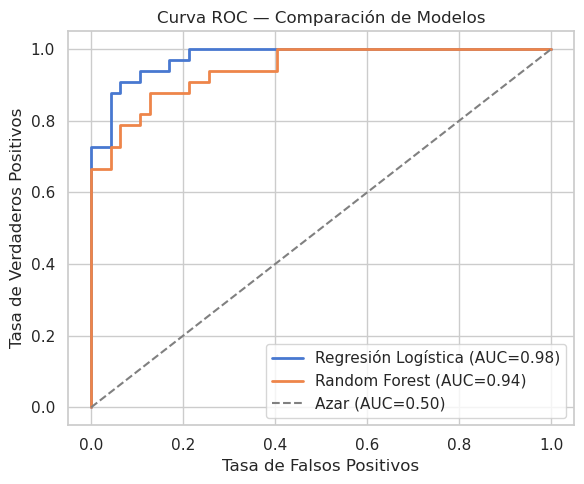

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

for nombre, modelo in modelos_optimizados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = resultados[nombre]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.2f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.50)")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC — Comparación de Modelos")
ax.legend()
plt.tight_layout()
plt.show()

La curva ROC confirma visualmente lo que ya mostraban los números: la curva de la Regresión Logística domina casi todo el rango sobre la del Random Forest, manteniéndose muy cerca de la esquina superior izquierda (clasificación perfecta), consistente con su AUC más alto (0.98 vs 0.94).

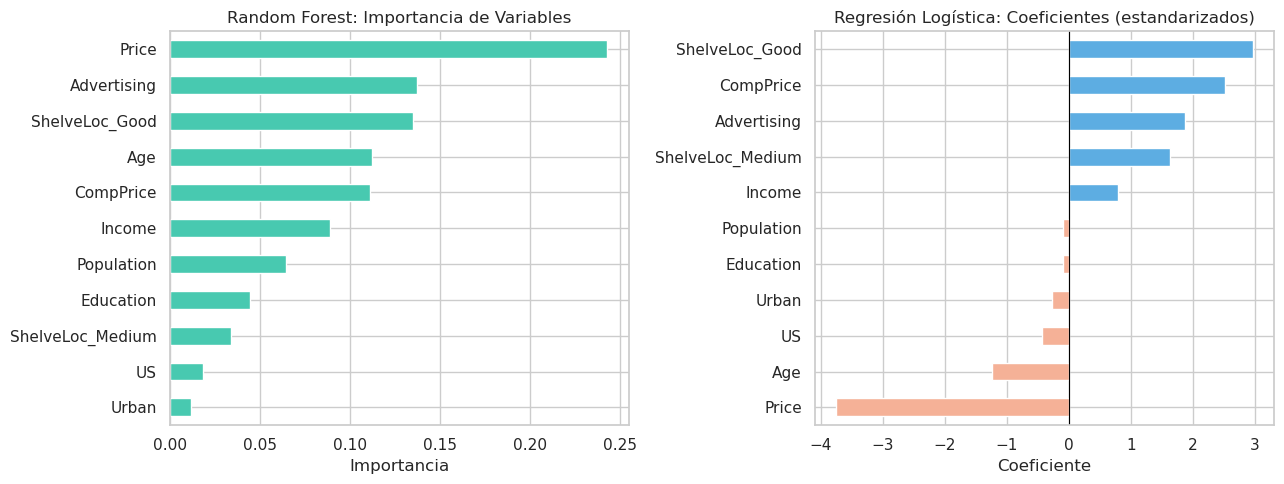

In [26]:
# Visualización de la importancia de variables y coeficientes
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

importancias_rf = pd.Series(
    modelos_optimizados["Random Forest"].named_steps["classifier"].feature_importances_,
    index=cols_X,
).sort_values()
importancias_rf.plot(kind="barh", ax=ejes[0], color="#48C9B0")
ejes[0].set_title("Random Forest: Importancia de Variables")
ejes[0].set_xlabel("Importancia")

coeficientes_lr = pd.Series(
    modelos_optimizados["Regresión Logística"].named_steps["classifier"].coef_[0],
    index=cols_X,
).sort_values()
colores = coeficientes_lr.apply(lambda valor: "#5DADE2" if valor > 0 else "#F5B197")
coeficientes_lr.plot(kind="barh", ax=ejes[1], color=colores)
ejes[1].set_title("Regresión Logística: Coeficientes (estandarizados)")
ejes[1].set_xlabel("Coeficiente")
ejes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

Ambos modelos coinciden en señalar a las mismas 3 variables como las más influyentes, lo que confirma con evidencia del modelo lo que el EDA solo sugería con correlaciones:

- **`Price`** es la variable más importante en los dos modelos (mayor importancia en Random Forest, coeficiente más grande en valor absoluto en la Regresión Logística: **-3.76**). El signo negativo confirma la relación esperada: a mayor precio, menor probabilidad de ventas altas.
- **`ShelveLoc_Good`** es la segunda más relevante (coeficiente **+2.97**): tener una buena ubicación en estantería aumenta fuertemente la probabilidad de ventas altas, tal como ya había mostrado el EDA (78% de ventas altas en tiendas `Good`).
- **`Advertising`** también aparece entre las 3 primeras en ambos modelos (coeficiente **+1.87**), consistente con el hallazgo del dashboard de que la publicidad alta casi duplica la tasa de ventas altas.

Un hallazgo nuevo que **no** era evidente en el EDA univariado: **`CompPrice`** tiene un coeficiente positivo y relativamente grande (**+2.52**) en la Regresión Logística, a pesar de tener una correlación débil con `Sales` (0.06) vista en la sección 2. La explicación es que su efecto solo se revela controlando por `Price` al mismo tiempo. Es decir, para un precio propio fijo, un competidor más caro es una ventaja competitiva relativa, justo la lógica detrás de la pregunta de negocio "¿conviene ser más barato que la competencia?" del dashboard. Es un buen ejemplo de por qué el modelado multivariado puede revelar relaciones que el análisis exploratorio variable por variable no alcanza a mostrar.

## 6. Conclusiones Generales


### 6.1 Problema y Hallazgos Principales

El dataset llegó limpio (sin nulos ni duplicados), lo que simplificó el ETL a su tarea central, que era convertir 4 columnas monetarias de USD a CLP mediante una API externa, y construir la variable objetivo `HighSales` (59% bajas / 41% altas, sin desbalance severo). El EDA identificó a `ShelveLoc` como la variable más asociada a las ventas por un margen amplio (78% de ventas altas en tiendas con buena ubicación vs 15% en las de mala ubicación), con `Price` y `Advertising` como predictores secundarios pero consistentes.

### 6.2 Resultados de Modelado

La Regresión Logística superó al Random Forest en todas las instancias de evaluación (validación cruzada, test, y curva ROC), algo distinto al patrón típico donde los ensembles suelen ganar. Ambos modelos coincidieron, sin embargo, en señalar a `Price`, `ShelveLoc_Good` y `Advertising` como las variables más influyentes, lo que **confirma con evidencia del modelo** lo que el EDA solo insinuaba con correlaciones. El hallazgo más interesante del proyecto fue el rol de `CompPrice` que fue invisible en el análisis univariado (correlación de 0.06 con `Sales`), pero relevante en el modelo multivariado, porque su efecto solo aparece al controlar por `Price` simultáneamente.

### 6.3 Decisiones Técnicas

Tres decisiones marcaron un diferencia en el desenlace de este proyecto:

- Escalado dentro del `Pipeline`, no antes del split, para evitar data leakage al garantizar que el `StandardScaler` solo aprendiera del conjunto de entrenamiento.
- `stratify=y` en el split y misma técnica de búsqueda (`GridSearchCV`) para ambos modelos.
- Separar el dashboard en `src/dashboard.py`, en lugar de una celda del notebook. Un servidor de Dash no "termina" como una celda normal, así que mantenerlo aparte fue lo que permitió que el notebook completo siguiera corriendo de principio a fin sin trabarse.

### 6.4 Limitaciones, Alcances y Mejoras Posibles

- **Tamaño de muestra**: 400 tiendas en total y solo 80 en el conjunto de prueba es poco para sacar conclusiones definitivas. Y las métricas reportadas tienen variabilidad inherente, mitigada parcialmente por la validación cruzada de 5 folds.
- **Solo se probaron 2 modelos**, según lo pedido por el enunciado. Un alcance natural sería sumar otro tipo para ver si alguno super la Regresión Lineal.
- **El umbral de clasificación quedó en el valor por defecto (0.5)**. Una mejora concreta sería ajustarlo según el costo real de negocio de un falso negativo (no detectar una tienda de ventas altas) versus un falso positivo, en vez de asumir que ambos errores cuestan lo mismo.
- **La interacción Price–CompPrice** que reveló la sección 5.5, y que el dashboard ya explora visualmente como "ventaja de precio", no se incorporó como variable explícita (por ejemplo, `CompPrice - Price`) en el modelo. Agregarla como feature derivada es una mejora directa y de bajo costo para una próxima iteración.